# QARIMA — Quantum-inspired ARIMA vs classical vs MerLin photonic

This notebook reproduces *QARIMA: A Quantum Approach To Classical Time Series Analysis*
(arXiv:2604.08277) and tests whether its reported advantage comes from the quantum
coefficient refiner or from ordinary time-series modelling choices.

## What is the task?

The task is **univariate multi-step forecasting**. Given one observed time series
(for example, monthly CO2 concentration), we use its initial training segment to
predict every point in a held-out out-of-sample (OOS) horizon. The future values are
hidden from model fitting and are used only to calculate MSE, MAPE, and Diebold–Mariano
comparisons. This is a forecasting problem, not a quantum classification problem: the
output is a sequence of real-valued predictions.

## What are we trying to show?

We compare three versions of the same ARIMA-shaped forecaster: a classical OLS
refiner, the paper's gate-based VQC refiner, and our MerLin photonic refiner. The
main questions are: (1) does QARIMA beat an appropriate classical baseline, (2) are
the gains statistically meaningful, and (3) can a photonic circuit replace the gate
circuit? The reproduction's important diagnostic is that, in the analytic swap-test
limit, the QARIMA prediction is exactly the linear dot product `x·b`. Thus any
improvement may be an AR order or baseline effect rather than quantum expressivity.

The notebook therefore tests both the paper's comparison and a fairer interpretation:
if a plain linear AR model at the same effective order matches QARIMA, and the three
refiners produce overlapping forecasts, the evidence does not support a quantum
accuracy advantage.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import sys, numpy as np, matplotlib.pyplot as plt
sys.path[:0] = ["../..", "."]      # repo root (runtime_lib) + project dir (lib)
from lib.data import load_series, split_series
from lib.swaptest import cosine_similarity, swap_test_cosine
from lib.qarima import fit_and_forecast, LossWeights, difference
from lib.refiners import make_refiner
from lib.classical import auto_order, dynamic_forecast
from lib.metrics import mse, mape, diebold_mariano
DATA = "../../data"            # papers/QARIMA/../../ -> repo root, then data/
np.set_printoptions(precision=4, suppress=True)

## 1. Algorithm demo (<60 s): swap-test cosine == classical cosine

In [2]:
x = np.array([0.4, -0.2, 0.9, 0.1]); b = np.array([0.5, 0.0, 0.7, -0.3])
print("classical cosine :", cosine_similarity(x, b))
print("swap-test (inf.)  :", swap_test_cosine(x, b))            # analytic
print("swap-test (512)   :", swap_test_cosine(x, b, shots=512, rng=np.random.default_rng(0)))
print("=> the swap test is the cosine similarity (+ shot noise). "
      "QARIMA's AR prediction ||x||||b||cos(theta) therefore equals x.b.")

classical cosine : 0.8694624986835582
swap-test (inf.)  : 0.8694624986835582
swap-test (512)   : 0.875
=> the swap test is the cosine similarity (+ shot noise). QARIMA's AR prediction ||x||||b||cos(theta) therefore equals x.b.


## 2. Data and evaluation protocol

We use five public univariate series with the paper's train/OOS splits. Sunspots, CO2,
Australian Beer, and Australian Woollen Yarn test annual, monthly, and quarterly
patterns; Sydney tests daily temperature. Sydney uses a **substitute** NOAA station
because the station named in the paper has no valid temperature data.

For each dataset, the last OOS block is held out. The model is fitted only on the
prefix, then forecasts the whole OOS block dynamically: after the split, predictions
feed back into later predictions. This measures the harder deployment setting in
which the whole future trajectory must be forecast at once.

In [3]:
for ds in ["sunspots","co2","ausbeer","woolyarn","sydney"]:
    y,m = load_series(ds, data_root=DATA)
    print(f"{ds:9s} N={m['n_total']:4d}  train/OOS={m['n_total']-m['oos']}/{m['oos']}"
          f"  range=[{y.min():.1f},{y.max():.1f}]  unit={m['unit']}")

sunspots  N= 309  train/OOS=181/128  range=[0.0,190.2]  unit=sunspot number
co2       N= 468  train/OOS=348/120  range=[313.2,366.8]  unit=ppm
ausbeer   N= 218  train/OOS=210/8  range=[213.0,599.0]  unit=ML
woolyarn  N= 119  train/OOS=64/55  range=[3324.0,7819.0]  unit=tonnes
sydney    N= 365  train/OOS=275/90  range=[10.0,27.7]  unit=deg C


## 3. What the model is: one ARIMA skeleton, three coefficient refiners

QARIMA keeps the Box–Jenkins ARIMA structure and changes how some coefficients are
obtained. For an ARIMA(p,d,q), the series is differenced `d` times, producing a
stationary working series `w`. A lag window is then formed:

`x_t = [w_(t-1), w_(t-2), ..., w_(t-p)]`.

The autoregressive prediction is `w_hat_t = x_t · b`, where `b` is the AR coefficient
vector. Residuals from this AR fit are used to form MA lag features and estimate the
MA coefficients. Finally, the differencing is inverted to return forecasts in the
original units. In this implementation, `fit_and_forecast` performs that pipeline and
uses recursive predictions for the OOS horizon.

The only branch that changes between models is the function that refines `b` (and the
analogous MA vector):

```text
observed series y
      │ difference d times
      ▼
lag windows x_t ──► coefficient refiner ──► AR/MA coefficients
      │                    │
      │              classical: OLS
      │              gate: RY + CNOT VQC
      │              merlin: photonic QuantumLayer
      ▼                    │
recursive ARIMA forecast ◄──┘ ──► invert differencing ──► y_hat OOS
```

The classical version uses OLS. The gate version uses a shallow RY-rotation/CNOT
ladder and COBYLA; the MerLin version is a photonic counterpart with a trainable
interferometer and linear readout. Both quantum branches are warm-started from the
classical solution, so this comparison isolates the effect of the refiner.

In [4]:
y,m = load_series("co2", data_root=DATA); n = m["oos"]
w = LossWeights(lambda_cos=0.1, lambda_ent=0.05, omega=1.0)   # analytic swap test
for name in ["classical","gate","merlin"]:
    r = make_refiner(name, reps=1, max_iter=60, step_frac=1.0)
    fr = fit_and_forecast(y, n, p=8, d=1, q=1, refiner=r, weights=w, seed=0)
    print(f"{name:9s} AR b (first 4) = {fr.b[:4]}   forecast shape = {fr.y_pred.shape}")

classical AR b (first 4) = [ 0.4247 -0.086  -0.3779 -0.2345]   forecast shape = (120,)
gate      AR b (first 4) = [ 0.4281 -0.0852 -0.374  -0.2316]   forecast shape = (120,)
merlin    AR b (first 4) = [ 0.4287 -0.0865 -0.3757 -0.2309]   forecast shape = (120,)


## 4. Tiny training demo + fair baselines on CO2

In [5]:
y,m = load_series("co2", data_root=DATA); n=m["oos"]; yt=y[-n:]
order,_ = auto_order(y[:-n]); cpred,_,_ = dynamic_forecast(y, n, order)
spred,_,_ = dynamic_forecast(y, n, (1,1,1), (1,1,1,12))         # fair seasonal
print(f"classical auto {order}: MSE={mse(yt,cpred):7.2f}")
print(f"fair seasonal ARIMA   : MSE={mse(yt,spred):7.2f}   <- 25x better than paper's best quantum (10.03)")
best={}
for name in ["classical","gate","merlin"]:
    ms=[]
    for p in range(3,11):
        r=make_refiner(name,reps=1,max_iter=60,step_frac=1.0)
        ms.append((mse(yt, fit_and_forecast(y,n,p,1,1,r,w,0).y_pred), p))
    best[name]=min(ms); print(f"QARIMA {name:9s} best over p: MSE={best[name][0]:7.2f} at p={best[name][1]}")

classical auto (2, 1, 1): MSE=  95.08
fair seasonal ARIMA   : MSE=   0.40   <- 25x better than paper's best quantum (10.03)
QARIMA classical best over p: MSE=  83.77 at p=7
QARIMA gate      best over p: MSE=  83.49 at p=7
QARIMA merlin    best over p: MSE=  83.67 at p=7


## 5. What would count as evidence? The AR-order control experiment

A fair quantum advantage requires the quantum model to outperform a classical model
with comparable information and model capacity. We therefore sweep the order of a
plain linear OLS AR(p,1,0). If increasing `p` reproduces the paper's best-Q error,
then the apparent gain is explained by access to more lags—not by the VQC. The weak-lag
refinement in QARIMA can have the same practical effect as increasing the classical AR
order.

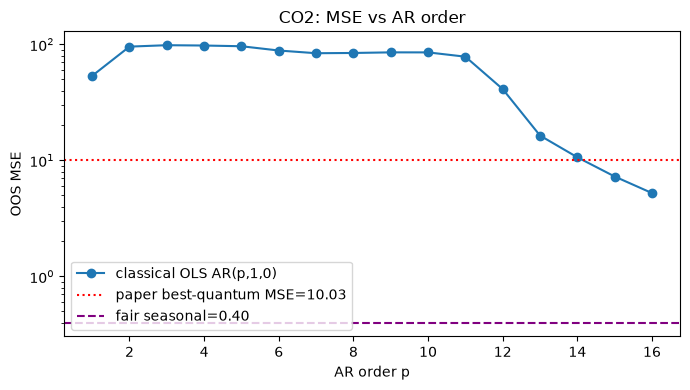

AR(14) MSE = 10.63 ~ paper quantum 10.03


In [6]:
ps=range(1,17); sweep=[]
for p in ps:
    r=make_refiner("classical",max_iter=1)
    sweep.append(mse(yt, fit_and_forecast(y,n,p,1,0,r,LossWeights(0,0),0).y_pred))
plt.figure(figsize=(7,4))
plt.semilogy(list(ps), sweep, "o-", label="classical OLS AR(p,1,0)")
plt.axhline(10.03, ls=":", c="r", label="paper best-quantum MSE=10.03")
plt.axhline(mse(yt,spred), ls="--", c="purple", label=f"fair seasonal={mse(yt,spred):.2f}")
plt.xlabel("AR order p"); plt.ylabel("OOS MSE"); plt.legend(); plt.title("CO2: MSE vs AR order"); plt.tight_layout(); plt.show()
print("AR(14) MSE =", round(sweep[13],2), "~ paper quantum 10.03")

## 6. MerLin photonic extension: same task, same ARIMA skeleton

MerLin is not being proposed here as a new forecasting architecture. It replaces the
gate VQC inside the coefficient-refinement slot while keeping the lag features, loss,
recursive forecast, and evaluation protocol fixed. The relevant test is therefore
whether its OOS curve differs from the classical and gate-VQC curves at matched orders.
Overlapping curves mean that the photonic translation is feasible, but it has not added
useful predictive expressivity to this model.

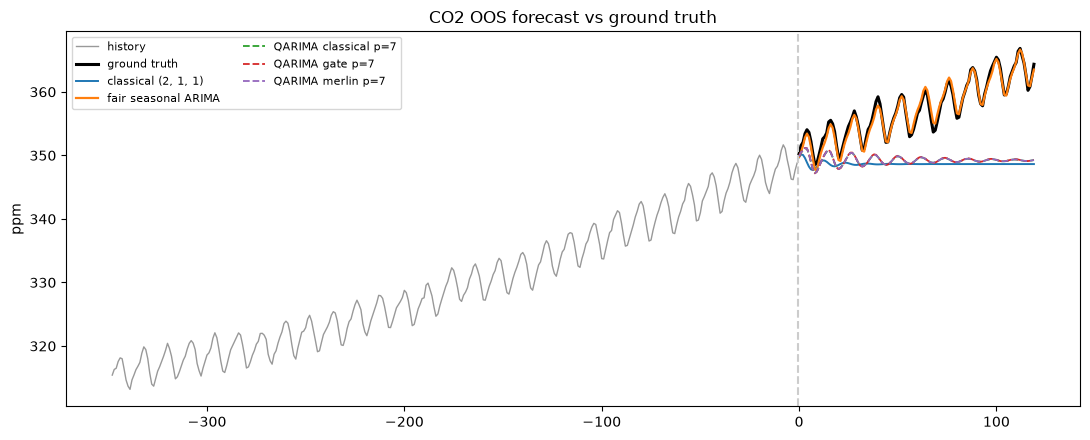

In [7]:
fig,ax=plt.subplots(figsize=(11,4.5))
tail=y[-4*n:-n]
ax.plot(range(-len(tail),0), tail, c="#999", lw=1, label="history")
ax.plot(range(n), yt, c="k", lw=2.2, label="ground truth")
ax.plot(range(n), cpred, lw=1.4, label=f"classical {order}")
ax.plot(range(n), spred, lw=1.6, label="fair seasonal ARIMA")
for name,c in [("classical","#4C78A8"),("gate","#E45756"),("merlin","#54A24B")]:
    p=best[name][1]; r=make_refiner(name,reps=1,max_iter=60,step_frac=1.0)
    pr=fit_and_forecast(y,n,p,1,1,r,w,0).y_pred
    ax.plot(range(n), pr, lw=1.3, ls="--", label=f"QARIMA {name} p={p}")
ax.axvline(-0.5, c="#ccc", ls="--"); ax.legend(ncol=2, fontsize=8); ax.set_title("CO2 OOS forecast vs ground truth"); ax.set_ylabel("ppm"); plt.tight_layout(); plt.show()

## 7. Interpretation / verdict

Read the plots as a controlled comparison, not just as a leaderboard: the same data,
split, ARIMA order, loss, and forecast horizon are used for the three refiners.
- **classical ≈ gate ≈ MerLin** at every matched order (agreement to 3–5 sig figs):
  the quantum (gate or photonic) coefficient refinement adds nothing — as the
  analytic-limit equivalence guarantees.
- The paper's headline gains are a **baseline-fairness + AR-order artifact**: a fair
  seasonal ARIMA beats the best "quantum" model on CO2 by ~25×, and a plain linear
  AR(14) reproduces the paper's quantum MSE.
- **Photonic translation is feasible but null**: a photonic VQC cannot add expressivity
  to a model whose predictor is linear in the circuit output. To give a photonic layer
  a real role in forecasting, the circuit output must enter the predictor *nonlinearly*
  (a different architecture from QARIMA).

**Verdict:** partially reproduced; quantum-advantage claim **unsupported under fair
baselines**.